# ESG Alpha Analysis: Fama-French 5-Factor Regression

## Objective
Test whether ESG Long/Short portfolios generate statistically significant alpha after controlling for the Fama-French factors:
- **Mkt-RF**: Market risk premium
- **SMB**: Size factor (Small Minus Big)
- **HML**: Value factor (High Minus Low)
- **RMW**: Profitability factor (Robust Minus Weak)
- **CMA**: Investment factor (Conservative Minus Aggressive)
- **WML** (added in section 5): Momentum factor

## Model Specification
$$R_{LS} = \alpha + \beta_{MKT}(R_m - R_f) + \beta_{SMB}\,SMB + \beta_{HML}\,HML + \beta_{RMW}\,RMW + \beta_{CMA}\,CMA + \epsilon$$

## Portfolios Tested
1. **Long-Short Quintile**: Long top 20% ESG, Short bottom 20% ESG (equal-weighted)
2. **Long-Short Decile**: Long top 10% ESG, Short bottom 10% ESG (equal-weighted)
3. **ESG-Weighted Long/Short** (Lioui-Tarelli 2022 style): full universe, weights proportional to the de-meaned ESG score


## 1. Setup & Data Loading


### 1.1 Imports and style


In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

### 1.2 File paths

**Modify paths below to point to your data files.**


In [2]:
# ============================================
# MODIFY THESE PATHS TO YOUR DATA FILES
# ============================================

# Path to ESG panel data (same as in ESG_Portfolio_Analysis.ipynb)
ESG_DATA_PATH = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/price_esg/ESG_Panel_With_Closing_Price.xlsx"

# Path to Fama-French 5 factors
FF_FACTORS_PATH = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/fama_french_factors/5_factors ff_US.csv"

# Path to Fama-French 6 factors (5 factors + Momentum)
FF_FACTORS_PATH = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/fama_french_factors/ff6_momentum_US.csv"

### 1.3 Load and prepare ESG panel

Returns are computed from closing prices, and ESG scores are lagged by one period to avoid look-ahead bias when forming portfolios.


In [3]:
# Load ESG Data
data = pd.read_excel(ESG_DATA_PATH, sheet_name="Panel Data")

# Data cleaning
data["Date"] = pd.to_datetime(data["Date"])
data["Closing_Price"] = pd.to_numeric(data["Closing_Price"], errors="coerce")
data = data.dropna(subset=["Closing_Price", "ESG"]).copy()

# Calculate returns
data = data.sort_values(["Ticker", "Date"])

data["Return"] = data.groupby("Ticker")["Closing_Price"].pct_change()

data["ESG_lag"] = data.groupby("Ticker")["ESG"].shift(1)

# Create quintiles and deciles (per date for cross-sectional ranking)
data["ESG_quintile"] = data.groupby("Date")["ESG_lag"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)
data["ESG_decile"] = data.groupby("Date")["ESG_lag"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
)

# Drop NaN returns (first observation per ticker)
data = data.dropna(subset=["Return"])

print(f"ESG Data shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print(f"Number of stocks: {data['Ticker'].nunique()}")
data.head()

ESG Data shape: (52421, 13)
Date range: 2015-02-01 00:00:00 to 2025-12-01 00:00:00
Number of stocks: 404


,Date,Ticker,Name,Sector,ESG,E,S,G,Closing_Price,Return,ESG_lag,ESG_quintile,ESG_decile
1,2015-02-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,37.64,0.125262,58.0,3.0,7.0
2,2015-03-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,38.68,0.027630,58.0,3.0,7.0
3,2015-04-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,36.95,-0.044726,58.0,3.0,7.0
4,2015-05-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,37.53,0.015697,58.0,3.0,7.0
5,2015-06-01,A,"Agilent Technologies, Inc.",Health Care,58,65,52,61,34.64,-0.077005,58.0,3.0,7.0


### 1.4 Load Fama-French 6 factors (FF5 + WML)


In [4]:
# Load Fama-French 6 Factors (5 factors + WML Momentum)
ff_raw = pd.read_csv(FF_FACTORS_PATH)

# Convert Date to string and filter only monthly data (6 characters: YYYYMM)
ff_raw['Date'] = ff_raw['Date'].astype(str).str.strip()
ff_monthly = ff_raw[ff_raw['Date'].str.len() == 6].copy()

# Convert to datetime
ff_monthly['Date'] = pd.to_datetime(ff_monthly['Date'], format='%Y%m')

# Convert factors from percentage to decimal
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'WML']
for col in factor_cols:
    ff_monthly[col] = pd.to_numeric(ff_monthly[col], errors='coerce') / 100

ff_monthly = ff_monthly.set_index('Date')

print(f"Fama-French data shape: {ff_monthly.shape}")
print(f"Date range: {ff_monthly.index.min()} to {ff_monthly.index.max()}")
print(f"WML available from: {ff_monthly['WML'].dropna().index.min()}")
#tail as momentum momentum data start later than the other factors
ff_monthly.tail(10)


Fama-French data shape: (751, 7)
Date range: 1963-07-01 00:00:00 to 2026-01-01 00:00:00
WML available from: 1990-11-01 00:00:00


,Mkt-RF,SMB,HML,RMW,CMA,RF,WML
Date,,,,,,,
2025-04-01,-0.0084,-0.0186,-0.0340,-0.0285,-0.0267,0.0035,0.0390
2025-05-01,0.0606,-0.0072,-0.0288,0.0129,0.0251,0.0038,-0.0051
2025-06-01,0.0486,-0.0002,-0.0161,-0.0320,0.0144,0.0034,-0.0234
2025-07-01,0.0198,-0.0015,-0.0127,-0.0031,-0.0207,0.0034,-0.0147
2025-08-01,0.0185,0.0488,0.0442,-0.0068,0.0208,0.0038,-0.0350
2025-09-01,0.0339,-0.0218,-0.0105,-0.0206,-0.0222,0.0033,0.0579
2025-10-01,0.0196,-0.0130,-0.0310,-0.0521,-0.0403,0.0037,0.0050
2025-11-01,-0.0013,0.0147,0.0376,0.0142,0.0068,0.0030,-0.0319
2025-12-01,-0.0036,-0.0022,0.0242,0.0040,0.0037,0.0034,-0.0207


## 2. Portfolio Construction

Three long/short ESG portfolios are constructed at each date $t$ using the **lagged** ESG score (information available at $t-1$):

1. **Quintile L/S**: long Q5 (top 20%), short Q1 (bottom 20%), equal-weighted within each leg.
2. **Decile L/S**: long D10 (top 10%), short D1 (bottom 10%), equal-weighted within each leg.
3. **ESG-weighted L/S** (Lioui & Tarelli, 2022): all stocks participate, with weights
$$w_{i,t-1} = \frac{\mathrm{ESG}_{i,t-1} - \overline{\mathrm{ESG}}_{t-1}}{\sum_j (\mathrm{ESG}_{j,t-1} - \overline{\mathrm{ESG}}_{t-1})^2}.$$

By construction, $\sum_i w_{i,t-1} = 0$ (zero-investment) and the realised return of this portfolio at $t$ equals the OLS slope of the cross-sectional regression of $r_{i,t}$ on $\mathrm{ESG}_{i,t-1}$.


In [5]:
def create_long_short_quintile(data):
    """
    ESG Long-Short Best-in-Class (Quintile)
    Long top quintile (Q4), Short bottom quintile (Q0)
    Equal-weighted within each leg
    """
    quintile_returns = data.groupby(['Date', 'ESG_quintile'])['Return'].mean().unstack()
    max_q = quintile_returns.columns.max()
    min_q = quintile_returns.columns.min()
    return quintile_returns[max_q] - quintile_returns[min_q]


def create_long_short_decile(data):
    """
    ESG Long-Short Best-in-Class (Decile)
    Long top decile (D9), Short bottom decile (D0)
    Equal-weighted within each leg
    """
    decile_returns = data.groupby(['Date', 'ESG_decile'])['Return'].mean().unstack()
    max_d = decile_returns.columns.max()
    min_d = decile_returns.columns.min()
    return decile_returns[max_d] - decile_returns[min_d]

def create_esg_weighted_portfolio(data):
    """
    ESG-weighted long/short portfolio (Lioui-Tarelli 2022 style).
    
    All stocks participate. Weights are proportional to the
    de-meaned ESG score :
        w_i = (ESG_i - mean(ESG)) / sum_j (ESG_j - mean(ESG))^2
    
    Properties :
      - sum(w_i) = 0  (zero-investment, by construction)
      - long high-ESG, short low-ESG, smooth transition (no quantile cutoff)
      - return at date t equals the OLS slope of the cross-sectional
        regression r_i,t on ESG_i,t-1
    """
    portfolio_returns = []
    
    for date, group in data.groupby('Date'):
        # de-mean ESG within the cross-section
        esg_centered = group['ESG_lag'] - group['ESG_lag'].mean()
        
        # denominator : sum of squared deviations
        denom = (esg_centered ** 2).sum()
        if denom == 0 or np.isnan(denom):
            continue
        
        # weights and portfolio return
        weights = esg_centered / denom
        ret = (weights * group['Return']).sum()
        portfolio_returns.append({'Date': date, 'Return': ret})
    
    return pd.DataFrame(portfolio_returns).set_index('Date')['Return']

# Build portfolios
print("Building Long-Short portfolios...")
ls_quintile = create_long_short_quintile(data)
ls_decile = create_long_short_decile(data)
ls_esg_weighted = create_esg_weighted_portfolio(data)

# Create DataFrame with portfolio returns
portfolios = pd.DataFrame({
    'LS_Quintile': ls_quintile,
    'LS_Decile': ls_decile,
    'LS_ESG_Weighted': ls_esg_weighted
})

print(f"\nPortfolio returns shape: {portfolios.shape}")
print(f"Date range: {portfolios.index.min()} to {portfolios.index.max()}")
portfolios.head(10)

Building Long-Short portfolios...

Portfolio returns shape: (131, 3)
Date range: 2015-02-01 00:00:00 to 2025-12-01 00:00:00


,LS_Quintile,LS_Decile,LS_ESG_Weighted
Date,,,
2015-02-01,-0.010786,0.005942,-0.000151
2015-03-01,-0.024632,-0.040047,-0.000628
2015-04-01,0.021326,0.013070,0.000340
2015-05-01,-0.014703,-0.002551,-0.000236
2015-06-01,-0.016277,-0.023101,-0.000363
2015-07-01,-0.053947,-0.049434,-0.000844
2015-08-01,-0.014068,-0.018504,-0.000181
2015-09-01,-0.010394,-0.003457,0.000131
2015-10-01,0.012995,0.020603,0.000206


## 3. Merge with Fama-French Factors


In [6]:
# Merge portfolio returns with Fama-French factors
# Align dates (both should be at month start)
regression_data = portfolios.join(ff_monthly, how='inner')

print(f"Merged data shape: {regression_data.shape}")
print(f"Date range: {regression_data.index.min()} to {regression_data.index.max()}")
print(f"\nNumber of observations: {len(regression_data)}")
regression_data.head(10)

Merged data shape: (131, 10)
Date range: 2015-02-01 00:00:00 to 2025-12-01 00:00:00

Number of observations: 131


,LS_Quintile,LS_Decile,LS_ESG_Weighted,Mkt-RF,SMB,HML,RMW,CMA,RF,WML
Date,,,,,,,,,,
2015-02-01,-0.010786,0.005942,-0.000151,0.0614,0.0036,-0.0179,-0.0110,-0.0175,0.0,-0.0231
2015-03-01,-0.024632,-0.040047,-0.000628,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0,0.0248
2015-04-01,0.021326,0.013070,0.000340,0.0060,-0.0301,0.0180,0.0005,-0.0062,0.0,-0.0684
2015-05-01,-0.014703,-0.002551,-0.000236,0.0138,0.0082,-0.0111,-0.0176,-0.0083,0.0,0.0579
2015-06-01,-0.016277,-0.023101,-0.000363,-0.0154,0.0290,-0.0082,0.0035,-0.0154,0.0,0.0287
2015-07-01,-0.053947,-0.049434,-0.000844,0.0157,-0.0458,-0.0416,0.0031,-0.0244,0.0,0.0747
2015-08-01,-0.014068,-0.018504,-0.000181,-0.0602,0.0029,0.0275,0.0066,0.0129,0.0,-0.0219
2015-09-01,-0.010394,-0.003457,0.000131,-0.0306,-0.0280,0.0055,0.0180,-0.0059,0.0,0.0327
2015-10-01,0.012995,0.020603,0.000206,0.0775,-0.0206,-0.0047,0.0095,0.0061,0.0,-0.0320


In [7]:
# Check for missing values
print("Missing values:")
print(regression_data.isnull().sum())

# Drop any rows with missing values
regression_data = regression_data.dropna()
print(f"\nFinal sample size: {len(regression_data)} months")

Missing values:
LS_Quintile        0
LS_Decile          0
LS_ESG_Weighted    0
Mkt-RF             0
SMB                0
HML                0
RMW                0
CMA                0
RF                 0
WML                0
dtype: int64

Final sample size: 131 months


## 4. Main Regressions: Fama-French 5-Factor

### Model
$$R_{LS,t} = \alpha + \beta_1 (Mkt-RF)_t + \beta_2\,SMB_t + \beta_3\,HML_t + \beta_4\,RMW_t + \beta_5\,CMA_t + \varepsilon_t$$

Standard errors are HAC-adjusted (Newey-West, 6 lags).

**Hypothesis:**
- $H_0$: $\alpha = 0$ (no abnormal return)
- $H_1$: $\alpha \neq 0$ (significant abnormal return)


### 4.0 Helper function and regressors


In [8]:
def run_ff5_regression(y, X, portfolio_name):
    """
    Run Fama-French 5-Factor regression and return results summary.
    
    Parameters:
    -----------
    y : Series - Portfolio returns (dependent variable)
    X : DataFrame - Fama-French factors (independent variables)
    portfolio_name : str - Name of the portfolio for display
    
    Returns:
    --------
    model : OLS regression results
    """
    # Add constant for intercept (alpha)
    X_with_const = sm.add_constant(X)
    
    # Run OLS regression with HAC standard errors (Newey-West)
    model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    
    print("="*80)
    print(f"FAMA-FRENCH 5-FACTOR REGRESSION: {portfolio_name}")
    print("="*80)
    print(f"\nSample Period: {y.index.min().strftime('%Y-%m')} to {y.index.max().strftime('%Y-%m')}")
    print(f"Number of Observations: {len(y)}")
    print("\n" + "="*80)
    print(model.summary())
    
    return model

In [9]:
# Define independent variables (Fama-French 5 factors)
X = regression_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]

### 4.1 Long-Short Quintile portfolio


In [10]:
# Regression for Long-Short Quintile
y_quintile = regression_data['LS_Quintile']
model_quintile = run_ff5_regression(y_quintile, X, "Long-Short Quintile (Top 20% - Bottom 20%)")
print(model_quintile.summary().tables[1])

FAMA-FRENCH 5-FACTOR REGRESSION: Long-Short Quintile (Top 20% - Bottom 20%)

Sample Period: 2015-02 to 2025-12
Number of Observations: 131

                            OLS Regression Results                            
Dep. Variable:            LS_Quintile   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     10.14
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.60e-08
Time:                        12:52:07   Log-Likelihood:                 387.81
No. Observations:                 131   AIC:                            -763.6
Df Residuals:                     125   BIC:                            -746.4
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025    

### 4.2 Long-Short Decile portfolio


In [11]:
# Regression for Long-Short Decile
y_decile = regression_data['LS_Decile']
model_decile = run_ff5_regression(y_decile, X, "Long-Short Decile (Top 10% - Bottom 10%)")

# print only last part of regression 
print(model_decile.summary().tables[1])

FAMA-FRENCH 5-FACTOR REGRESSION: Long-Short Decile (Top 10% - Bottom 10%)

Sample Period: 2015-02 to 2025-12
Number of Observations: 131

                            OLS Regression Results                            
Dep. Variable:              LS_Decile   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     9.726
Date:                Wed, 06 May 2026   Prob (F-statistic):           7.26e-08
Time:                        12:52:07   Log-Likelihood:                 340.41
No. Observations:                 131   AIC:                            -668.8
Df Residuals:                     125   BIC:                            -651.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      

### 4.3 ESG-weighted Long-Short portfolio (Lioui-Tarelli style)

All stocks participate with weights proportional to their de-meaned ESG score. This avoids the discretionary cutoff of quintile/decile sorting and improves diversification across the whole cross-section.


In [12]:
# Regression for ESG-weighted portfolio (Lioui-Tarelli style)
y_weighted = regression_data['LS_ESG_Weighted']
model_weighted = run_ff5_regression(
    y_weighted, X,
    "ESG-Weighted Long/Short (full universe, de-meaned weights)"
)
print(model_weighted.summary().tables[1])

FAMA-FRENCH 5-FACTOR REGRESSION: ESG-Weighted Long/Short (full universe, de-meaned weights)

Sample Period: 2015-02 to 2025-12
Number of Observations: 131

                            OLS Regression Results                            
Dep. Variable:        LS_ESG_Weighted   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     19.18
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.98e-14
Time:                        12:52:07   Log-Likelihood:                 892.48
No. Observations:                 131   AIC:                            -1773.
Df Residuals:                     125   BIC:                            -1756.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|

### 4.4 Summary across the three portfolios


In [13]:
def create_results_summary(models, names):
    """
    Create a summary table of regression results.
    """
    results = []
    
    for model, name in zip(models, names):
        alpha = model.params['const']
        alpha_tstat = model.tvalues['const']
        alpha_pval = model.pvalues['const']
        
        # Annualized alpha (monthly * 12)
        alpha_annual = alpha * 12
        
        result = {
            'Portfolio': name,
            'Alpha (Monthly)': f"{alpha:.4f}",
            'Alpha (Annual)': f"{alpha_annual:.4f}",
            'Alpha (Annual %)': f"{alpha_annual*100:.2f}%",
            't-stat': f"{alpha_tstat:.3f}",
            'p-value': f"{alpha_pval:.4f}",
            'Significant (5%)': '✓ Yes' if alpha_pval < 0.05 else '✗ No',
            'Significant (10%)': '✓ Yes' if alpha_pval < 0.10 else '✗ No',
            'R²': f"{model.rsquared:.4f}",
            'Adj. R²': f"{model.rsquared_adj:.4f}",
            'Mkt-RF β': f"{model.params['Mkt-RF']:.4f}",
            'SMB β': f"{model.params['SMB']:.4f}",
            'HML β': f"{model.params['HML']:.4f}",
            'RMW β': f"{model.params['RMW']:.4f}",
            'CMA β': f"{model.params['CMA']:.4f}"
        }
        results.append(result)
    
    return pd.DataFrame(results)


# Create summary table
summary_df = create_results_summary(
    [model_quintile, model_decile, model_weighted],
    ['Long-Short Quintile', 'Long-Short Decile', 'ESG-Weighted']
)

print("\n" + "="*100)
print("ALPHA ANALYSIS SUMMARY")
print("="*100)
print("\nKey Results:")
print(summary_df[['Portfolio', 'Alpha (Annual %)', 't-stat', 'p-value', 'Significant (5%)', 'R²']].to_string(index=False))


ALPHA ANALYSIS SUMMARY

Key Results:
          Portfolio Alpha (Annual %) t-stat p-value Significant (5%)     R²
Long-Short Quintile           -5.60% -3.887  0.0001            ✓ Yes 0.2498
  Long-Short Decile           -5.50% -2.824  0.0047            ✓ Yes 0.1787
       ESG-Weighted           -0.10% -3.082  0.0021            ✓ Yes 0.2730


In [14]:
# Detailed factor loadings
print("\n" + "="*100)
print("FACTOR LOADINGS (BETAS)")
print("="*100)
print("\nInterpretation:")
print("- Mkt-RF β > 0: Portfolio has market exposure (should be ~0 for long-short)")
print("- SMB β > 0: Tilted towards small caps")
print("- HML β > 0: Tilted towards value stocks")
print("- RMW β > 0: Tilted towards profitable stocks")
print("- CMA β > 0: Tilted towards conservative (low investment) stocks")
print()
print(summary_df[['Portfolio', 'Mkt-RF β', 'SMB β', 'HML β', 'RMW β', 'CMA β']].to_string(index=False))


FACTOR LOADINGS (BETAS)

Interpretation:
- Mkt-RF β > 0: Portfolio has market exposure (should be ~0 for long-short)
- SMB β > 0: Tilted towards small caps
- HML β > 0: Tilted towards value stocks
- RMW β > 0: Tilted towards profitable stocks
- CMA β > 0: Tilted towards conservative (low investment) stocks

          Portfolio Mkt-RF β   SMB β  HML β   RMW β  CMA β
Long-Short Quintile  -0.0279 -0.1650 0.0364 -0.0899 0.2085
  Long-Short Decile  -0.0151 -0.1336 0.0003 -0.0751 0.3277
       ESG-Weighted  -0.0007 -0.0039 0.0003 -0.0018 0.0048


In [15]:
# Full results table
print("\n" + "="*100)
print("COMPLETE RESULTS TABLE")
print("="*100)
display(summary_df.T)


COMPLETE RESULTS TABLE


,0,1,2
Portfolio,Long-Short Quintile,Long-Short Decile,ESG-Weighted
Alpha (Monthly),-0.0047,-0.0046,-0.0001
Alpha (Annual),-0.0560,-0.0550,-0.0010
Alpha (Annual %),-5.60%,-5.50%,-0.10%
t-stat,-3.887,-2.824,-3.082
p-value,0.0001,0.0047,0.0021
Significant (5%),✓ Yes,✓ Yes,✓ Yes
Significant (10%),✓ Yes,✓ Yes,✓ Yes
R²,0.2498,0.1787,0.2730
Adj. R²,0.2198,0.1458,0.2439


In [16]:
# Check AIC and BIC for model comparison
print("\nModel Comparison:")
print(f"Long-Short Quintile: AIC = {model_quintile.aic:.2f}, BIC = {model_quintile.bic:.2f}")
print(f"Long-Short Decile: AIC = {model_decile.aic:.2f}, BIC = {model_decile.bic:.2f}")



Model Comparison:
Long-Short Quintile: AIC = -763.62, BIC = -746.37
Long-Short Decile: AIC = -668.81, BIC = -651.56


## 5. Augmented Models: Adding Momentum (WML)

We add the Momentum factor (WML) to test whether the ESG alpha survives once the momentum exposure is controlled for. WML is only available from 1990-11 onwards, so the sample is restricted accordingly.


### 5.1 Generic regression helper (handles missing WML)


In [17]:
def run_regression(y, X, portfolio_name, model_label):
    """Régression OLS avec HAC standard errors (Newey-West)."""
    # Aligner et nettoyer les NaN (important car WML manque avant 1990-11)
    df = pd.concat([y, X], axis=1).dropna()
    y_clean = df.iloc[:, 0]
    X_clean = df.iloc[:, 1:]
    
    X_with_const = sm.add_constant(X_clean)
    model = sm.OLS(y_clean, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    
    print("="*80)
    print(f"{model_label}: {portfolio_name}")
    print("="*80)
    print(f"Sample Period: {y_clean.index.min().strftime('%Y-%m')} to {y_clean.index.max().strftime('%Y-%m')}")
    print(f"Number of Observations: {len(y_clean)}")
    print("\n" + "="*80)
    print(model.summary())
    return model

### 5.2 FF6 regression on the Quintile portfolio


In [18]:
# FF 6-Factor (FF5 + Momentum) — Quintile
X_ff6 = regression_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'WML']]

model_quintile_ff6 = run_regression(y_quintile, X_ff6,
                                     "Long-Short Quintile", "FAMA-FRENCH 6-FACTOR REGRESSION")
print(model_quintile_ff6.summary().tables[1])

FAMA-FRENCH 6-FACTOR REGRESSION: Long-Short Quintile
Sample Period: 2015-02 to 2025-12
Number of Observations: 131

                            OLS Regression Results                            
Dep. Variable:            LS_Quintile   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     9.006
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.64e-08
Time:                        12:52:08   Log-Likelihood:                 393.01
No. Observations:                 131   AIC:                            -772.0
Df Residuals:                     124   BIC:                            -751.9
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------

### 5.3 Direct comparison FF5 vs FF6 on the same sub-sample

To assess the marginal contribution of Momentum, we re-estimate FF5 and FF6 on the same restricted sample (post 1990-11) where WML is available.


In [19]:
# Comparaison directe FF5 vs FF6 : voir l'impact d'ajouter Momentum sur les autres facteurs
def compare_ff5_vs_ff6(y, portfolio_name):
    """Compare FF5 et FF6 sur le MÊME échantillon (post-1990-11) pour comparaison équitable."""
    # Aligner sur l'échantillon où WML existe
    df = pd.concat([y, regression_data[['Mkt-RF','SMB','HML','RMW','CMA','WML']]], axis=1).dropna()
    y_c = df.iloc[:, 0]
    
    # FF5 sur échantillon restreint
    X5 = sm.add_constant(df[['Mkt-RF','SMB','HML','RMW','CMA']])
    m5 = sm.OLS(y_c, X5).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    
    # FF6 sur même échantillon
    X6 = sm.add_constant(df[['Mkt-RF','SMB','HML','RMW','CMA','WML']])
    m6 = sm.OLS(y_c, X6).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    
    factors = ['const','Mkt-RF','SMB','HML','RMW','CMA','WML']
    rows = []
    for f in factors:
        ff5_coef = f"{m5.params[f]:.4f}" if f in m5.params else "—"
        ff5_t = f"({m5.tvalues[f]:.2f})" if f in m5.tvalues else "—"
        ff6_coef = f"{m6.params[f]:.4f}"
        ff6_t = f"({m6.tvalues[f]:.2f})"
        rows.append([f, ff5_coef, ff5_t, ff6_coef, ff6_t])
    
    comp = pd.DataFrame(rows, columns=['Factor','FF5 Coef','FF5 t-stat','FF6 Coef','FF6 t-stat'])
    
    print(f"\n{'='*80}\n{portfolio_name} — FF5 vs FF6 (sample: {y_c.index.min():%Y-%m} to {y_c.index.max():%Y-%m}, N={len(y_c)})\n{'='*80}")
    print(comp.to_string(index=False))
    print(f"\nAlpha annualized: FF5 = {m5.params['const']*12*100:.2f}% | FF6 = {m6.params['const']*12*100:.2f}%")
    print(f"R² adj:           FF5 = {m5.rsquared_adj:.4f} | FF6 = {m6.rsquared_adj:.4f}")
    print(f"AIC:              FF5 = {m5.aic:.2f} | FF6 = {m6.aic:.2f}")
    print(f"BIC:              FF5 = {m5.bic:.2f} | FF6 = {m6.bic:.2f}")
    return m5, m6, comp

m5_q, m6_q, comp_q = compare_ff5_vs_ff6(y_quintile, "Long-Short Quintile")
m5_d, m6_d, comp_d = compare_ff5_vs_ff6(y_decile, "Long-Short Decile")


Long-Short Quintile — FF5 vs FF6 (sample: 2015-02 to 2025-12, N=131)
Factor FF5 Coef FF5 t-stat FF6 Coef FF6 t-stat
 const  -0.0047    (-3.89)  -0.0042    (-3.60)
Mkt-RF  -0.0279    (-0.97)  -0.0407    (-1.52)
   SMB  -0.1650    (-3.34)  -0.1972    (-4.11)
   HML   0.0364     (1.00)  -0.0053    (-0.13)
   RMW  -0.0899    (-1.29)  -0.1249    (-1.83)
   CMA   0.2085     (4.06)   0.2425     (4.10)
   WML        —          —  -0.1193    (-2.71)

Alpha annualized: FF5 = -5.60% | FF6 = -5.06%
R² adj:           FF5 = 0.2198 | FF6 = 0.2735
AIC:              FF5 = -763.62 | FF6 = -772.01
BIC:              FF5 = -746.37 | FF6 = -751.89

Long-Short Decile — FF5 vs FF6 (sample: 2015-02 to 2025-12, N=131)
Factor FF5 Coef FF5 t-stat FF6 Coef FF6 t-stat
 const  -0.0046    (-2.82)  -0.0040    (-2.49)
Mkt-RF  -0.0151    (-0.26)  -0.0309    (-0.54)
   SMB  -0.1336    (-1.80)  -0.1733    (-2.57)
   HML   0.0003     (0.01)  -0.0511    (-0.87)
   RMW  -0.0751    (-0.84)  -0.1182    (-1.29)
   CMA   0.3277

## 6. Diagnostics

Before drawing conclusions, we check three classical pitfalls of factor regressions:

1. **Multicollinearity** between regressors (correlation matrix and VIF).
2. **Time variation in factor exposures** (rolling FF5 betas).
3. **Residual autocorrelation** (ACF and Ljung-Box test).


### 6.1 Correlation matrix and Variance Inflation Factors

Rule of thumb: VIF > 5 signals concerning multicollinearity, VIF > 10 a serious problem. On Fama-French US factors, all VIFs should be below ~3.


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Correlation matrix between factors and ESG portfolios
corr_matrix = regression_data[
    ['LS_Quintile', 'LS_Decile', 'LS_ESG_Weighted',
     'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
].corr()

print("Correlation matrix :")
print(corr_matrix.round(3))

# VIF on the regressors (Fama-French factors only)
X_const = sm.add_constant(X)
vif = pd.DataFrame({
    'Variable': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
print("\nVariance Inflation Factors :")
print(vif.round(3))

Correlation matrix :
                 LS_Quintile  LS_Decile  LS_ESG_Weighted  Mkt-RF    SMB  \
LS_Quintile            1.000      0.754            0.926  -0.261 -0.272   
LS_Decile              0.754      1.000            0.803  -0.177 -0.165   
LS_ESG_Weighted        0.926      0.803            1.000  -0.284 -0.330   
Mkt-RF                -0.261     -0.177           -0.284   1.000  0.310   
SMB                   -0.272     -0.165           -0.330   0.310  1.000   
HML                    0.176      0.168            0.119  -0.003  0.336   
RMW                    0.064      0.066            0.082  -0.014 -0.332   
CMA                    0.376      0.372            0.362  -0.211  0.043   

                   HML    RMW    CMA  
LS_Quintile      0.176  0.064  0.376  
LS_Decile        0.168  0.066  0.372  
LS_ESG_Weighted  0.119  0.082  0.362  
Mkt-RF          -0.003 -0.014 -0.211  
SMB              0.336 -0.332  0.043  
HML              1.000  0.153  0.631  
RMW              0.153  1.000 

### 6.2 Factor correlation heatmap (FF5 + Momentum)


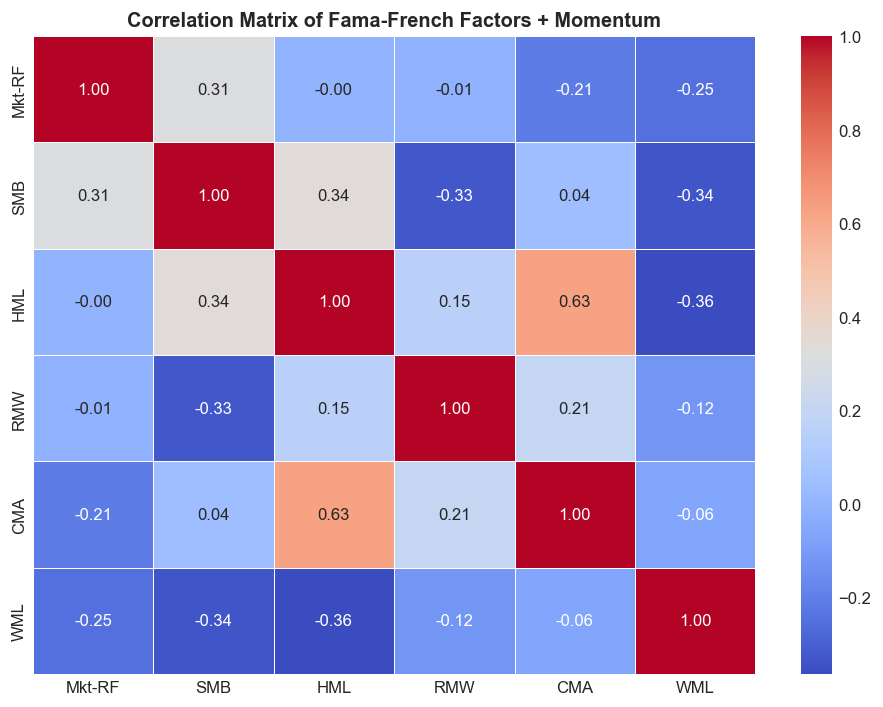

In [21]:
import seaborn as sns

# Matrice de corrélation factorielle
factor_data = regression_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'WML']].dropna()
corr_matrix = factor_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Fama-French Factors + Momentum', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Factor_Correlation_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Rolling 36-month FF5 betas

If betas (especially SMB or HML) drift substantially over time, the static FF5 regression of section 4 underestimates dynamic exposure instability. More stable rolling betas for the ESG-weighted portfolio would suggest that this construction is mechanically better diversified than the quintile sort.


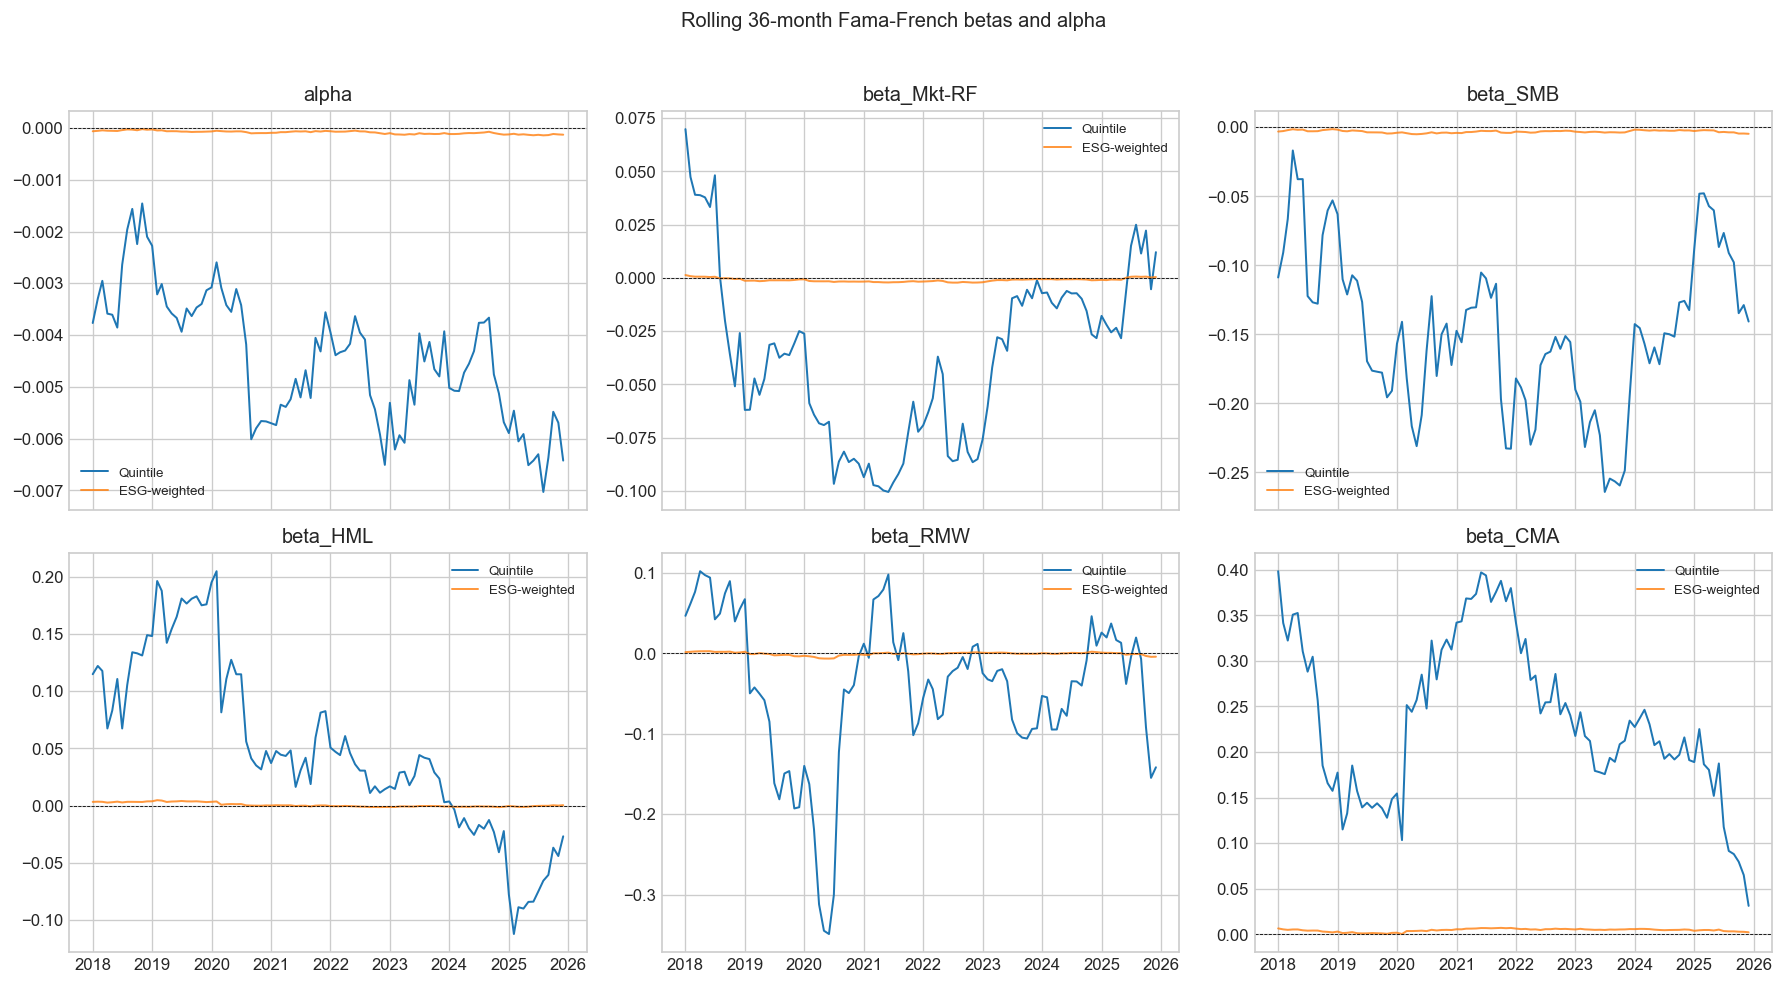

In [22]:
def rolling_ff5_betas(y, X, window=36):
    """
    Rolling Fama-French 5-factor regression on a fixed window.
    Returns a DataFrame containing alpha and beta estimates for each
    rolling window end-date.
    """
    X_const = sm.add_constant(X)
    out = []
    
    for end in range(window, len(y) + 1):
        y_win = y.iloc[end - window:end]
        X_win = X_const.iloc[end - window:end]
        
        try:
            m = sm.OLS(y_win, X_win).fit()
            row = {'Date': y_win.index[-1], 'alpha': m.params['const']}
            for f in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']:
                row[f'beta_{f}'] = m.params[f]
            out.append(row)
        except Exception:
            continue
    
    return pd.DataFrame(out).set_index('Date')


# Apply to the three portfolios
rolling_q = rolling_ff5_betas(regression_data['LS_Quintile'], X, window=36)
rolling_d = rolling_ff5_betas(regression_data['LS_Decile'], X, window=36)
rolling_w = rolling_ff5_betas(regression_data['LS_ESG_Weighted'], X, window=36)

# Plot rolling betas for the quintile portfolio
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, col in zip(axes.flat, ['alpha', 'beta_Mkt-RF', 'beta_SMB', 'beta_HML', 'beta_RMW', 'beta_CMA']):
    ax.plot(rolling_q.index, rolling_q[col], label='Quintile', linewidth=1.2)
    ax.plot(rolling_w.index, rolling_w[col], label='ESG-weighted', linewidth=1.2, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle("Rolling 36-month Fama-French betas and alpha", y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Rolling 12-month alpha (Quintile portfolio)


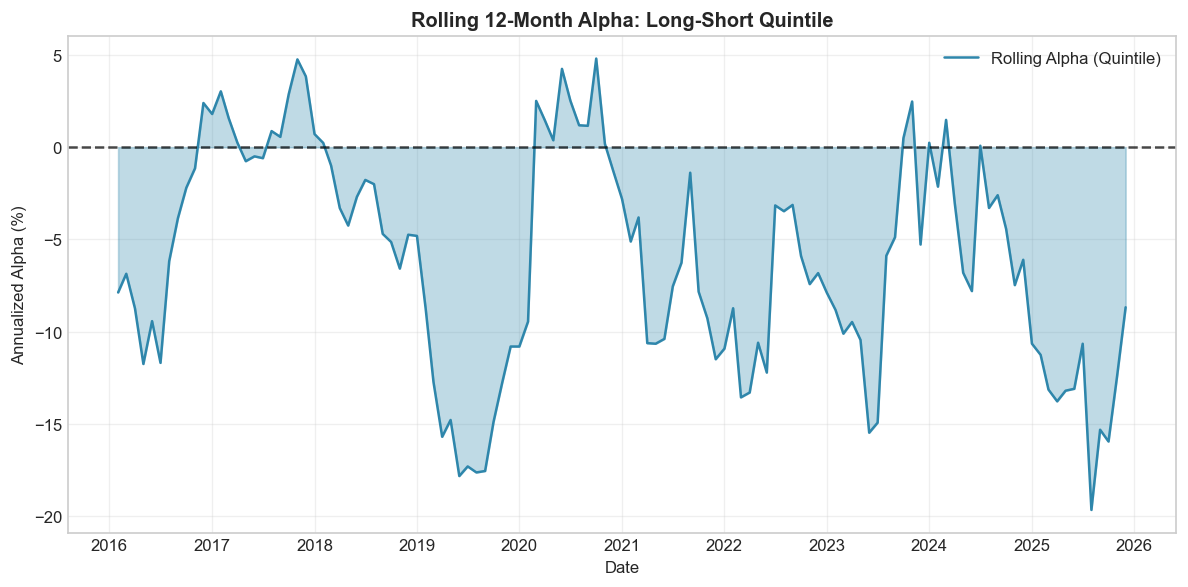

In [23]:
# Rolling 12-month alpha for the Quintile portfolio
# (recomputed here so the cell is self-contained and does not depend on section 8)
rolling_alpha_q = []
rolling_dates = []
for i in range(12, len(regression_data)):
    y_roll = regression_data['LS_Quintile'].iloc[i-12:i]
    X_roll = regression_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].iloc[i-12:i]
    X_roll_const = sm.add_constant(X_roll)
    try:
        model_roll = sm.OLS(y_roll, X_roll_const).fit()
        rolling_alpha_q.append(model_roll.params['const'] * 12 * 100)  # Annualized %
        rolling_dates.append(regression_data.index[i])
    except Exception:
        pass

plt.figure(figsize=(10, 5))
plt.plot(rolling_dates, rolling_alpha_q, label='Rolling Alpha (Quintile)', color='#2E86AB')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.fill_between(rolling_dates, rolling_alpha_q, 0, alpha=0.3, color='#2E86AB')
plt.title('Rolling 12-Month Alpha: Long-Short Quintile', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Annualized Alpha (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Rolling_Alpha_Quintile.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.5 Residual diagnostics (ACF and Ljung-Box test)

Test whether the Newey-West correction (6 lags) is sufficient to handle residual autocorrelation.


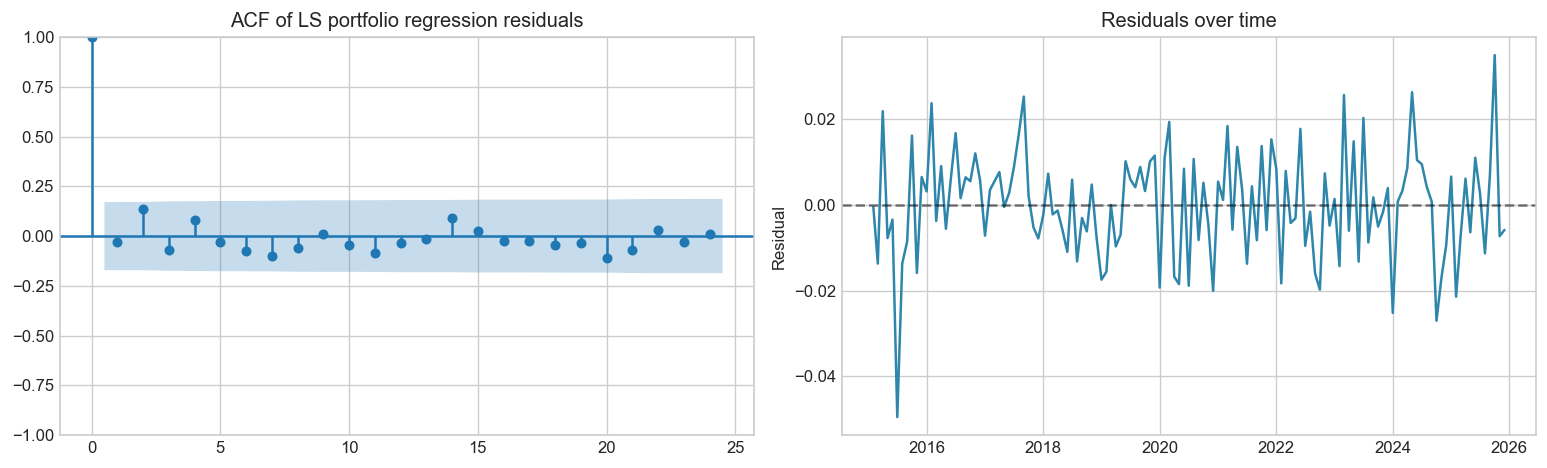

Ljung-Box test for autocorrelation in residuals:
     lb_stat  lb_pvalue
6   5.115822   0.529046
12  8.617185   0.735233


In [24]:
# Pour ta régression TS du portefeuille LS (ancien notebook)
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_quintile.resid  # ou ton modèle équivalent

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) ACF plot
plot_acf(residuals, lags=24, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of LS portfolio regression residuals')

# (b) Residuals over time
axes[1].plot(residuals.index, residuals.values, color='#2E86AB')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Residuals over time')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

# Ljung-Box test
lb = acorr_ljungbox(residuals, lags=[6, 12], return_df=True)
print("Ljung-Box test for autocorrelation in residuals:")
print(lb)

## 7. Robustness Checks


### 7.1 Nested model comparison (CAPM, FF3, FF5)

Compare the alpha estimate as we move from a single-factor (CAPM) model to the full FF5 specification, to check that conclusions are not driven by a single model choice.


In [25]:
# Robustness: CAPM (1-Factor) vs 3-Factor vs 5-Factor comparison
print("="*100)
print("ROBUSTNESS CHECK: Model Comparison")
print("="*100)

def compare_models(y, X_full, portfolio_name):
    """Compare CAPM, FF3, and FF5 models."""
    results = []
    
    # CAPM (1-Factor)
    X_capm = sm.add_constant(X_full[['Mkt-RF']])
    model_capm = sm.OLS(y, X_capm).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    results.append({
        'Model': 'CAPM',
        'Alpha (Ann. %)': model_capm.params['const'] * 12 * 100,
        't-stat': model_capm.tvalues['const'],
        'p-value': model_capm.pvalues['const'],
        'R²': model_capm.rsquared
    })
    
    # Fama-French 3-Factor
    X_ff3 = sm.add_constant(X_full[['Mkt-RF', 'SMB', 'HML']])
    model_ff3 = sm.OLS(y, X_ff3).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    results.append({
        'Model': 'FF 3-Factor',
        'Alpha (Ann. %)': model_ff3.params['const'] * 12 * 100,
        't-stat': model_ff3.tvalues['const'],
        'p-value': model_ff3.pvalues['const'],
        'R²': model_ff3.rsquared
    })
    
    # Fama-French 5-Factor
    X_ff5 = sm.add_constant(X_full)
    model_ff5 = sm.OLS(y, X_ff5).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    results.append({
        'Model': 'FF 5-Factor',
        'Alpha (Ann. %)': model_ff5.params['const'] * 12 * 100,
        't-stat': model_ff5.tvalues['const'],
        'p-value': model_ff5.pvalues['const'],
        'R²': model_ff5.rsquared
    })
    
    df = pd.DataFrame(results)
    df['Significant (5%)'] = df['p-value'].apply(lambda x: '✓' if x < 0.05 else '')
    
    print(f"\n{portfolio_name}:")
    print(df.to_string(index=False))
    
    return df

# Compare for both portfolios
comparison_quintile = compare_models(y_quintile, X, "Long-Short Quintile")
comparison_decile = compare_models(y_decile, X, "Long-Short Decile")

ROBUSTNESS CHECK: Model Comparison

Long-Short Quintile:
      Model  Alpha (Ann. %)    t-stat  p-value       R² Significant (5%)
       CAPM       -5.077621 -3.273871 0.001061 0.067871                ✓
FF 3-Factor       -5.736798 -3.833282 0.000126 0.177761                ✓
FF 5-Factor       -5.596495 -3.887369 0.000101 0.249787                ✓

Long-Short Decile:
      Model  Alpha (Ann. %)    t-stat  p-value       R² Significant (5%)
       CAPM       -5.038858 -2.516391 0.011856 0.031157                ✓
FF 3-Factor       -5.611372 -2.729872 0.006336 0.094194                ✓
FF 5-Factor       -5.503856 -2.823697 0.004747 0.178685                ✓


### 7.2 Sub-period analysis

Split the sample in half to check whether the ESG alpha is stable across sub-periods, or driven by a single regime.


In [26]:
# Sub-period analysis
print("\n" + "="*100)
print("ROBUSTNESS CHECK: Sub-Period Analysis")
print("="*100)

# Split sample into two halves
midpoint = len(regression_data) // 2
first_half = regression_data.iloc[:midpoint]
second_half = regression_data.iloc[midpoint:]

print(f"\nFirst Half: {first_half.index.min().strftime('%Y-%m')} to {first_half.index.max().strftime('%Y-%m')} ({len(first_half)} months)")
print(f"Second Half: {second_half.index.min().strftime('%Y-%m')} to {second_half.index.max().strftime('%Y-%m')} ({len(second_half)} months)")

def subperiod_analysis(data, period_name):
    """Run regression on subperiod."""
    y_q = data['LS_Quintile']
    y_d = data['LS_Decile']
    X_sub = sm.add_constant(data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']])
    
    model_q = sm.OLS(y_q, X_sub).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    model_d = sm.OLS(y_d, X_sub).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    
    print(f"\n{period_name}:")
    print(f"  Long-Short Quintile: Alpha = {model_q.params['const']*12*100:.2f}% (t={model_q.tvalues['const']:.2f}, p={model_q.pvalues['const']:.3f})")
    print(f"  Long-Short Decile:   Alpha = {model_d.params['const']*12*100:.2f}% (t={model_d.tvalues['const']:.2f}, p={model_d.pvalues['const']:.3f})")
    
    return model_q, model_d

models_first = subperiod_analysis(first_half, "First Half")
models_second = subperiod_analysis(second_half, "Second Half")


ROBUSTNESS CHECK: Sub-Period Analysis

First Half: 2015-02 to 2020-06 (65 months)
Second Half: 2020-07 to 2025-12 (66 months)

First Half:
  Long-Short Quintile: Alpha = -4.19% (t=-1.93, p=0.054)
  Long-Short Decile:   Alpha = -3.92% (t=-1.27, p=0.202)

Second Half:
  Long-Short Quintile: Alpha = -6.23% (t=-3.65, p=0.000)
  Long-Short Decile:   Alpha = -7.32% (t=-3.73, p=0.000)


## 8. Visualizations

Figures summarising the main results: cumulative returns, rolling alphas, and factor loadings.


### 8.1 Cumulative returns and rolling alpha overview


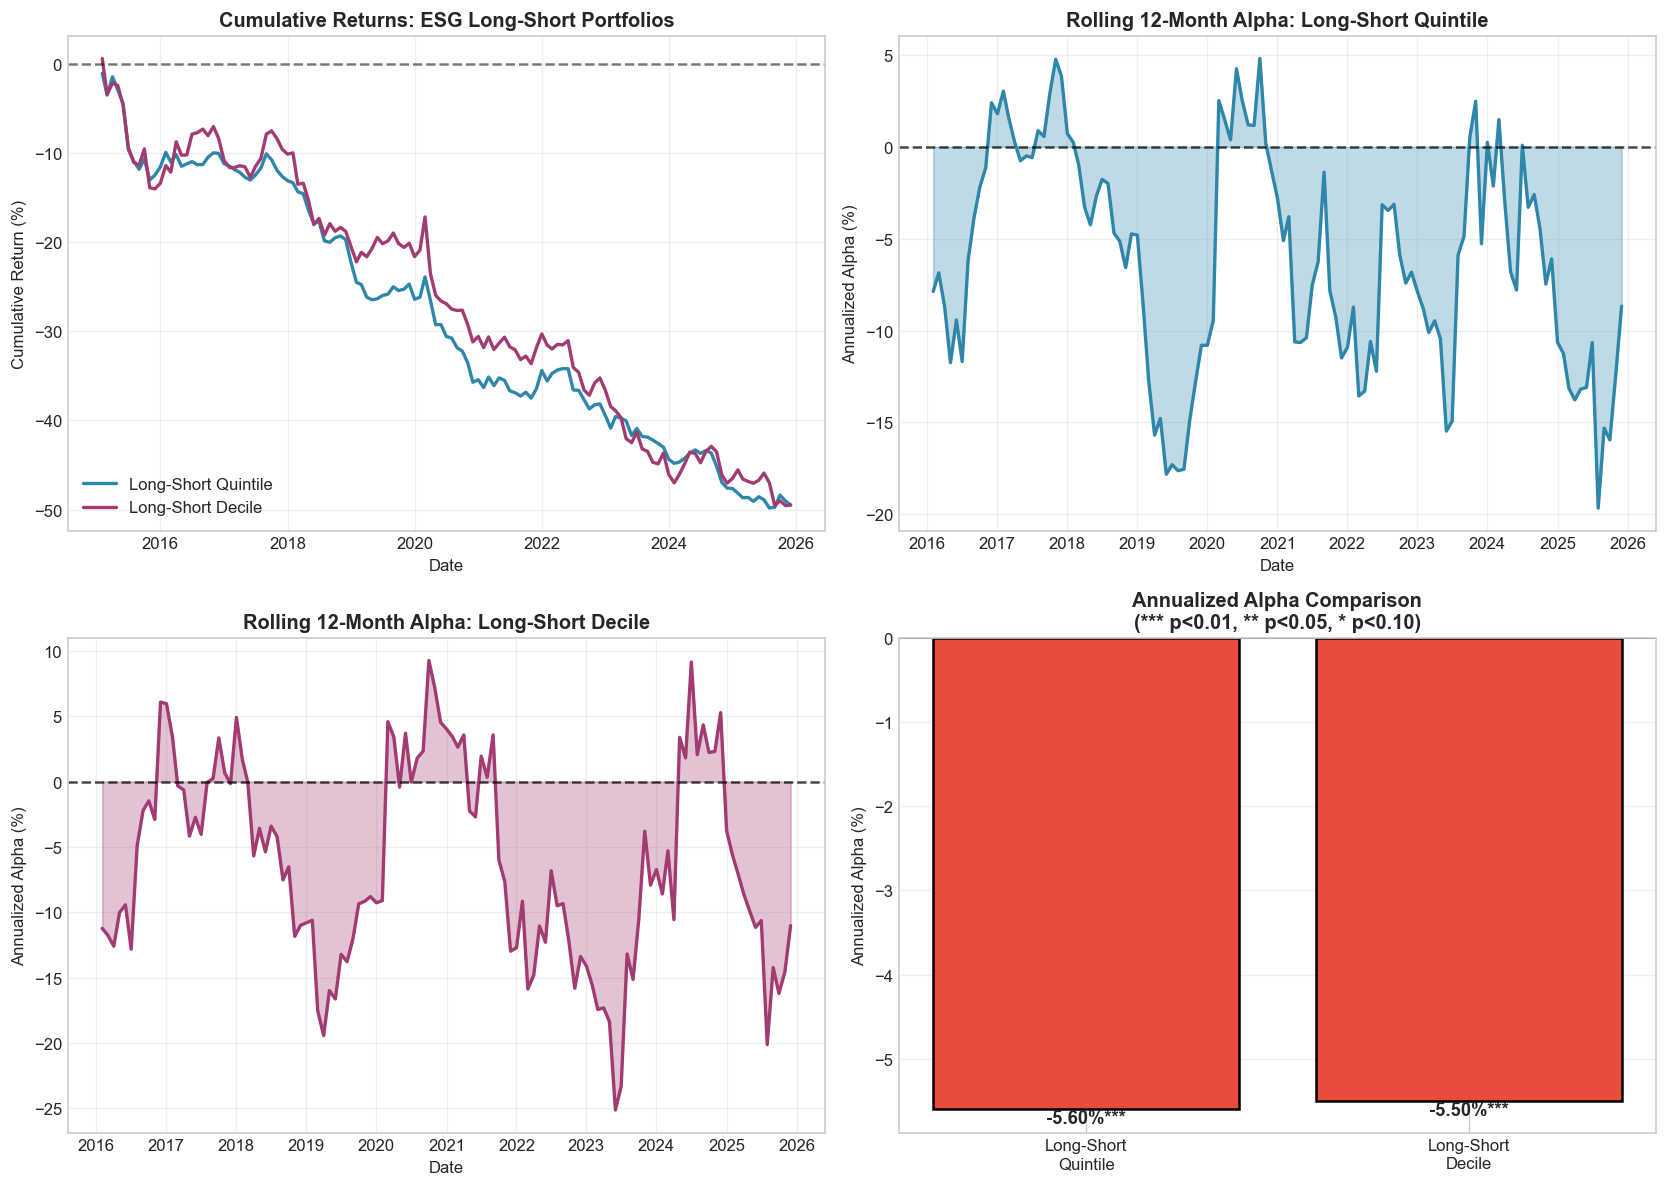

In [27]:
# Plot cumulative returns of Long-Short portfolios
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cumulative Returns
ax1 = axes[0, 0]
cum_quintile = (1 + regression_data['LS_Quintile']).cumprod() - 1
cum_decile = (1 + regression_data['LS_Decile']).cumprod() - 1

ax1.plot(cum_quintile.index, cum_quintile * 100, label='Long-Short Quintile', linewidth=2, color='#2E86AB')
ax1.plot(cum_decile.index, cum_decile * 100, label='Long-Short Decile', linewidth=2, color='#A23B72')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Cumulative Returns: ESG Long-Short Portfolios', fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Rolling 12-month Alpha (Quintile)
ax2 = axes[0, 1]
rolling_alpha_q = []
rolling_dates = []
for i in range(12, len(regression_data)):
    y_roll = regression_data['LS_Quintile'].iloc[i-12:i]
    X_roll = regression_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].iloc[i-12:i]
    X_roll_const = sm.add_constant(X_roll)
    try:
        model_roll = sm.OLS(y_roll, X_roll_const).fit()
        rolling_alpha_q.append(model_roll.params['const'] * 12 * 100)  # Annualized %
        rolling_dates.append(regression_data.index[i])
    except:
        pass

ax2.plot(rolling_dates, rolling_alpha_q, linewidth=2, color='#2E86AB')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.7)
ax2.fill_between(rolling_dates, rolling_alpha_q, 0, alpha=0.3, color='#2E86AB')
ax2.set_title('Rolling 12-Month Alpha: Long-Short Quintile', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Annualized Alpha (%)')
ax2.grid(True, alpha=0.3)

# 3. Rolling 12-month Alpha (Decile)
ax3 = axes[1, 0]
rolling_alpha_d = []
rolling_dates_d = []
for i in range(12, len(regression_data)):
    y_roll = regression_data['LS_Decile'].iloc[i-12:i]
    X_roll = regression_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].iloc[i-12:i]
    X_roll_const = sm.add_constant(X_roll)
    try:
        model_roll = sm.OLS(y_roll, X_roll_const).fit()
        rolling_alpha_d.append(model_roll.params['const'] * 12 * 100)  # Annualized %
        rolling_dates_d.append(regression_data.index[i])
    except:
        pass

ax3.plot(rolling_dates_d, rolling_alpha_d, linewidth=2, color='#A23B72')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.7)
ax3.fill_between(rolling_dates_d, rolling_alpha_d, 0, alpha=0.3, color='#A23B72')
ax3.set_title('Rolling 12-Month Alpha: Long-Short Decile', fontsize=12, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Annualized Alpha (%)')
ax3.grid(True, alpha=0.3)

# 4. Alpha Bar Chart Comparison
ax4 = axes[1, 1]
portfolios_names = ['Long-Short\nQuintile', 'Long-Short\nDecile']
alphas = [model_quintile.params['const'] * 12 * 100, model_decile.params['const'] * 12 * 100]
colors = ['#2E86AB' if a > 0 else '#E74C3C' for a in alphas]
pvals = [model_quintile.pvalues['const'], model_decile.pvalues['const']]

bars = ax4.bar(portfolios_names, alphas, color=colors, edgecolor='black', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Add significance stars
for i, (bar, pval) in enumerate(zip(bars, pvals)):
    height = bar.get_height()
    star = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    ax4.annotate(f'{height:.2f}%{star}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=11, fontweight='bold')

ax4.set_title('Annualized Alpha Comparison\n(*** p<0.01, ** p<0.05, * p<0.10)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Annualized Alpha (%)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ESG_Alpha_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Factor loadings (FF5 betas across portfolios)


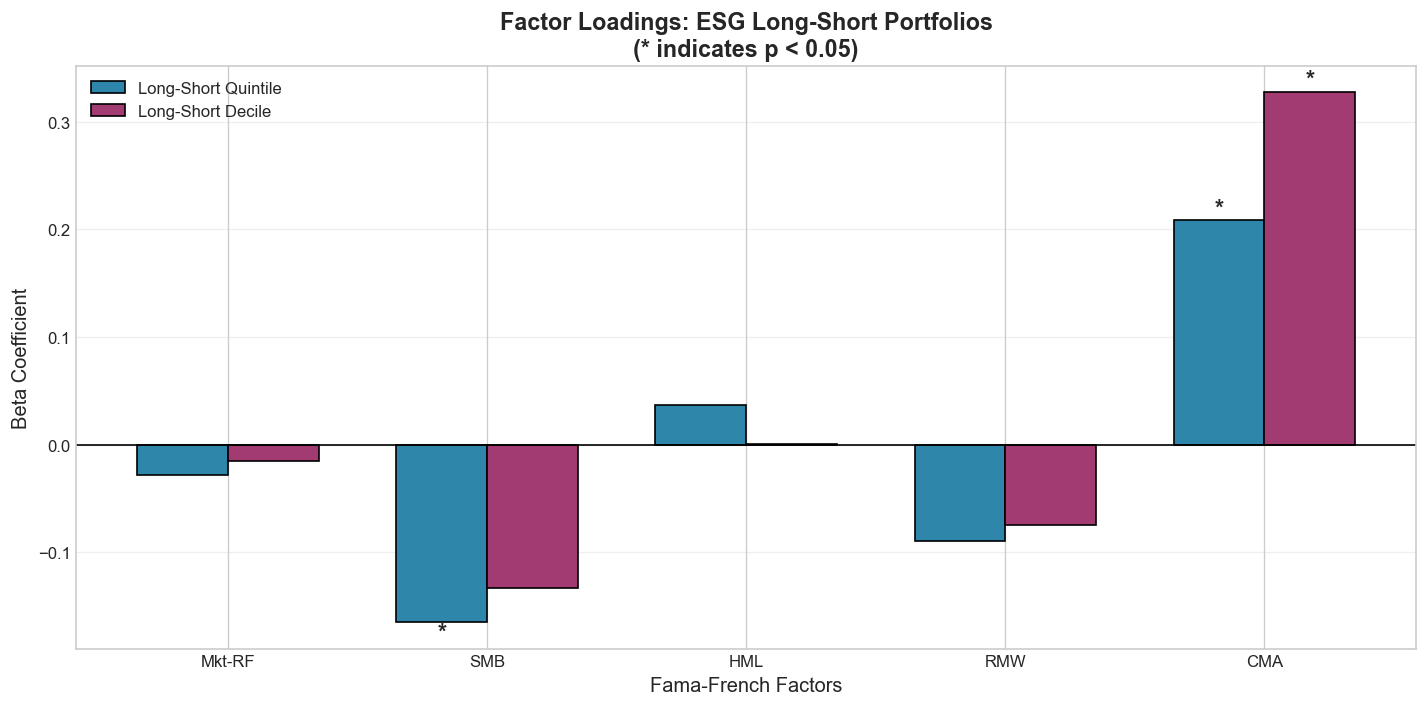

In [28]:
# Factor Loadings Visualization
fig, ax = plt.subplots(figsize=(12, 6))

factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
x = np.arange(len(factors))
width = 0.35

# Get betas and p-values
betas_q = [model_quintile.params[f] for f in factors]
betas_d = [model_decile.params[f] for f in factors]
pvals_q = [model_quintile.pvalues[f] for f in factors]
pvals_d = [model_decile.pvalues[f] for f in factors]

bars1 = ax.bar(x - width/2, betas_q, width, label='Long-Short Quintile', color='#2E86AB', edgecolor='black')
bars2 = ax.bar(x + width/2, betas_d, width, label='Long-Short Decile', color='#A23B72', edgecolor='black')

# Add significance indicators
for i, (bar, pval) in enumerate(zip(bars1, pvals_q)):
    if pval < 0.05:
        height = bar.get_height()
        ax.annotate('*', xy=(bar.get_x() + bar.get_width()/2, height),
                   ha='center', va='bottom' if height > 0 else 'top', fontsize=14, fontweight='bold')

for i, (bar, pval) in enumerate(zip(bars2, pvals_d)):
    if pval < 0.05:
        height = bar.get_height()
        ax.annotate('*', xy=(bar.get_x() + bar.get_width()/2, height),
                   ha='center', va='bottom' if height > 0 else 'top', fontsize=14, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Fama-French Factors', fontsize=12)
ax.set_ylabel('Beta Coefficient', fontsize=12)
ax.set_title('Factor Loadings: ESG Long-Short Portfolios\n(* indicates p < 0.05)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(factors)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ESG_Factor_Loadings.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusion


In [29]:
print("\n" + "="*100)
print("CONCLUSION: ESG ALPHA ANALYSIS")
print("="*100)

alpha_q = model_quintile.params['const'] * 12 * 100
alpha_d = model_decile.params['const'] * 12 * 100
pval_q = model_quintile.pvalues['const']
pval_d = model_decile.pvalues['const']

print(f"""
MAIN FINDINGS:
─────────────────────────────────────────────────────────────────────────────────

1. LONG-SHORT QUINTILE PORTFOLIO (Top 20% ESG - Bottom 20% ESG)
   • Annualized Alpha: {alpha_q:.2f}%
   • Statistical Significance: {'Significant at 5%' if pval_q < 0.05 else 'Significant at 10%' if pval_q < 0.10 else 'Not Significant'} (p = {pval_q:.4f})
   • Interpretation: {'Positive alpha suggests ESG leaders outperform ESG laggards' if alpha_q > 0 else 'Negative alpha suggests ESG laggards outperform ESG leaders'}

2. LONG-SHORT DECILE PORTFOLIO (Top 10% ESG - Bottom 10% ESG)
   • Annualized Alpha: {alpha_d:.2f}%
   • Statistical Significance: {'Significant at 5%' if pval_d < 0.05 else 'Significant at 10%' if pval_d < 0.10 else 'Not Significant'} (p = {pval_d:.4f})
   • Interpretation: {'Positive alpha suggests ESG leaders outperform ESG laggards' if alpha_d > 0 else 'Negative alpha suggests ESG laggards outperform ESG leaders'}

KEY TAKEAWAYS:
─────────────────────────────────────────────────────────────────────────────────
""")

if alpha_q > 0 and pval_q < 0.05:
    print("• Strong evidence that HIGH ESG firms outperform LOW ESG firms after risk adjustment.")
    print("• The ESG premium is economically meaningful and statistically significant.")
elif alpha_q < 0 and pval_q < 0.05:
    print("• Strong evidence that LOW ESG firms outperform HIGH ESG firms after risk adjustment.")
    print("• This suggests an ESG 'discount' rather than premium.")
elif abs(alpha_q) > 0 and pval_q < 0.10:
    print("• Weak evidence of ESG-related abnormal returns (significant at 10% level).")
    print("• Results should be interpreted with caution.")
else:
    print("• No statistically significant alpha found.")
    print("• ESG characteristics do not appear to generate abnormal returns after controlling for known risk factors.")
    print("• This is consistent with market efficiency regarding ESG information.")

print(f"""
─────────────────────────────────────────────────────────────────────────────────
Note: Standard errors are HAC-adjusted (Newey-West) to account for autocorrelation.
Sample period: {regression_data.index.min().strftime('%Y-%m')} to {regression_data.index.max().strftime('%Y-%m')} ({len(regression_data)} months)
""")


CONCLUSION: ESG ALPHA ANALYSIS

MAIN FINDINGS:
─────────────────────────────────────────────────────────────────────────────────

1. LONG-SHORT QUINTILE PORTFOLIO (Top 20% ESG - Bottom 20% ESG)
   • Annualized Alpha: -5.60%
   • Statistical Significance: Significant at 5% (p = 0.0001)
   • Interpretation: Negative alpha suggests ESG laggards outperform ESG leaders

2. LONG-SHORT DECILE PORTFOLIO (Top 10% ESG - Bottom 10% ESG)
   • Annualized Alpha: -5.50%
   • Statistical Significance: Significant at 5% (p = 0.0047)
   • Interpretation: Negative alpha suggests ESG laggards outperform ESG leaders

KEY TAKEAWAYS:
─────────────────────────────────────────────────────────────────────────────────

• Strong evidence that LOW ESG firms outperform HIGH ESG firms after risk adjustment.
• This suggests an ESG 'discount' rather than premium.

─────────────────────────────────────────────────────────────────────────────────
Note: Standard errors are HAC-adjusted (Newey-West) to account for autoco